# **Curated Disease Dataset for Predictive Health Analysis:**

# **About the Author:**

**Name: Adil Zaman**

**Email ID: zamanadil61@gmail.com**

**Kaggle ID: https://www.kaggle.com/zemnukes98**

**Github ID: https://github.com/AdilZaman98**

**Linkedin ID: https://www.linkedin.com/in/adil-zaman-85b56a398/**

#

**This dataset is derived from the Breast Cancer Wisconsin (Diagnostic) dataset and is widely used for binary classification tasks in medical machine learning.**

**It contains features computed from digitized images of fine needle aspirate (FNA) biopsies of breast masses. Each sample represents measurements of cell nuclei characteristics, which are used to classify tumors as malignant or benign.**

**The dataset is well-suited for:**

- **Breast cancer diagnosis modeling**
  
- **Binary classification tasks**
  
- **Feature importance and explainability studies**
  
- **Healthcare-focused machine learning projects**
  
- **Academic coursework and benchmarking ML models**

# **Automated Classification of Benign and Malignant Tumors from Medical Image Features:**
  
**The goal is to predict whether a tumor is malignant or benign based on quantitative cellular features extracted from medical images.**

**Now to explore the EDA of the dataset;**

# **Exploratory Data Analysis:**

In [28]:
#Let's start the project by importing all the libraries for that particular dataset
import pandas as pd
import numpy as np
# To visualize the dataset
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# To preprocess the dataset
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,MinMaxScaler,RobustScaler,PowerTransformer
from sklearn.impute import SimpleImputer,KNNImputer
# to import the iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
# for machine learning tasks
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
# for classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
# for regression tasks
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
# import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


Now to load the dataset;

# **Load the dataset:**

In [3]:
df=pd.read_csv('data.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


**Now to see the sneak-peak of the dataset;**

# **Sneak-Peak of the Dataset:**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
df.shape

(569, 33)

**Here we see that there were 569 rows and 33 columns.**

In [7]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [8]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [9]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [10]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


**The counts yells us the no columns has missing values which has to be imputed except an unknown column.**

# **Imputation of the dataset:**

In [16]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

**We usually remove that column in order to refine the dataset;**

In [18]:
df.drop(columns=['Unnamed: 32'], errors='ignore', inplace=True)

**Now to visualise the imputation;**


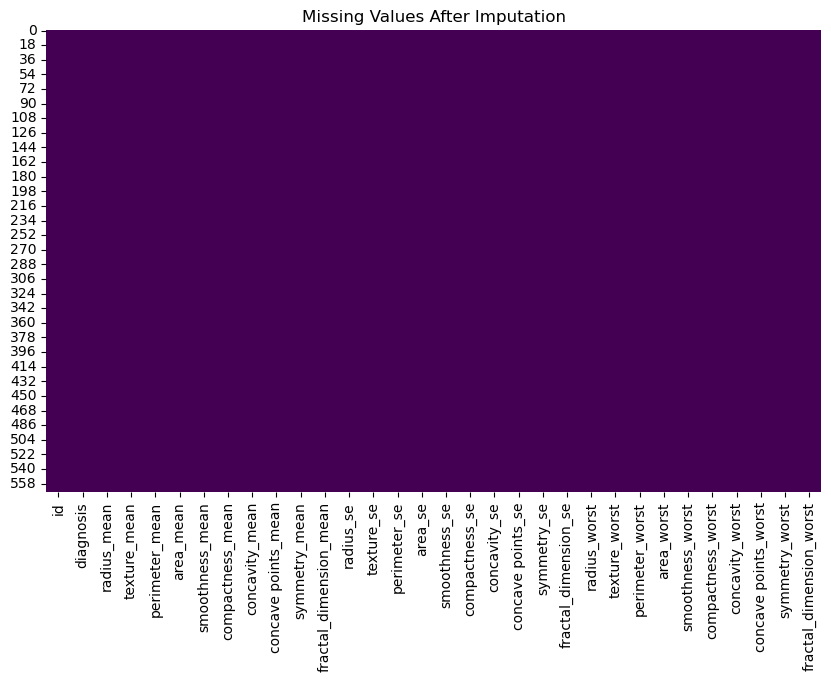

In [19]:
# Make a code in python that visualize the imputation of dataset after managing all the missing values
df.isnull().sum()
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values After Imputation')
plt.show()


**Now to check the outliers from the dataset;**

# **Outliers from the dataset:**

In [20]:
# Sirf numeric columns select karein
numeric_cols = df.select_dtypes(include=['number']).columns

# Loop through each numeric column
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Outliers count karein
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    
    if outlier_count > 0:
        print(f"Column '{col}' has {outlier_count} outliers.")


Column 'id' has 81 outliers.
Column 'radius_mean' has 14 outliers.
Column 'texture_mean' has 7 outliers.
Column 'perimeter_mean' has 13 outliers.
Column 'area_mean' has 25 outliers.
Column 'smoothness_mean' has 6 outliers.
Column 'compactness_mean' has 16 outliers.
Column 'concavity_mean' has 18 outliers.
Column 'concave points_mean' has 10 outliers.
Column 'symmetry_mean' has 15 outliers.
Column 'fractal_dimension_mean' has 15 outliers.
Column 'radius_se' has 38 outliers.
Column 'texture_se' has 20 outliers.
Column 'perimeter_se' has 38 outliers.
Column 'area_se' has 65 outliers.
Column 'smoothness_se' has 30 outliers.
Column 'compactness_se' has 28 outliers.
Column 'concavity_se' has 22 outliers.
Column 'concave points_se' has 19 outliers.
Column 'symmetry_se' has 27 outliers.
Column 'fractal_dimension_se' has 28 outliers.
Column 'radius_worst' has 17 outliers.
Column 'texture_worst' has 5 outliers.
Column 'perimeter_worst' has 15 outliers.
Column 'area_worst' has 35 outliers.
Column

In [21]:
# Copy of the original dataframe
df_clean = df.copy()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Sirf woh rows rakhein jo bounds ke andar hain
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

Original shape: (569, 32)
Cleaned shape: (233, 32)


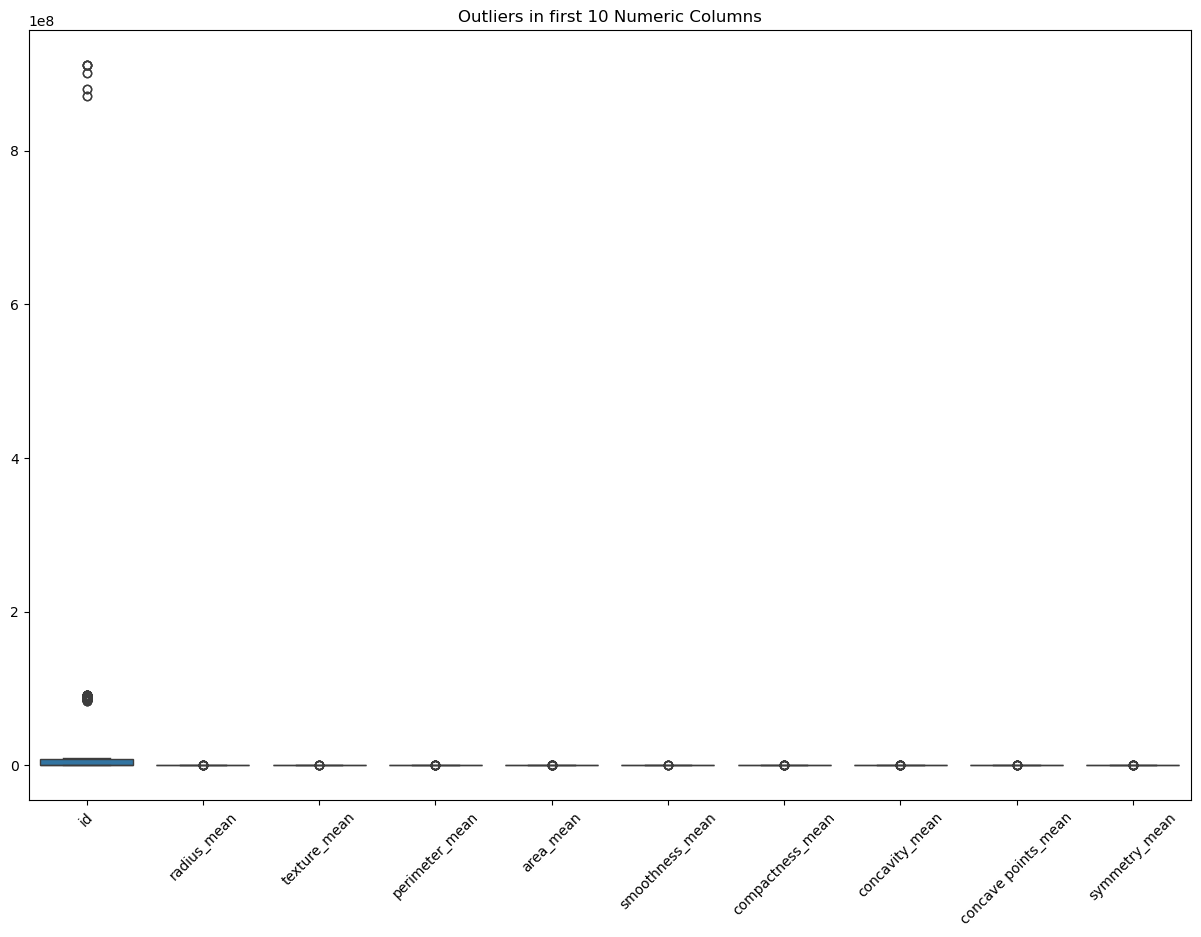

In [22]:
# Pehle 10 numeric columns ka boxplot dekhne ke liye
plt.figure(figsize=(15, 10))
sns.boxplot(data=df[numeric_cols[:10]])
plt.xticks(rotation=45)
plt.title("Outliers in first 10 Numeric Columns")
plt.show()

# **Breast Cancer Tumor Malignancy Prediction Using Multiple Machine Learning Classifiers:**

>**This Python code loads the Breast Cancer Wisconsin (Diagnostic) dataset, cleans it by handling missing values and encoding the target, and then builds and evaluates seven different machine learning models (Logistic Regression, Decision Tree, Random Forest, SVM, KNN, Gradient Boosting, Naive Bayes) to predict whether a tumor is malignant or benign. It compares model performance using accuracy, confusion matrices, classification reports, ROC curves, and performs hyperparameter tuning on Random Forest for optimized results.**

Dataset shape: (569, 31)

First 5 rows:
   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0    

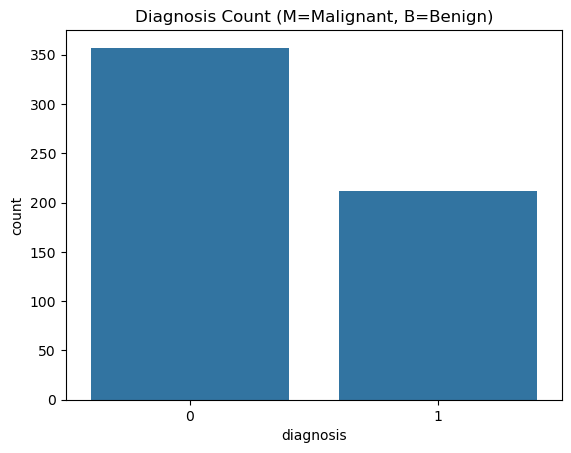


Feature statistics:
        diagnosis  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  569.000000   569.000000    569.000000      569.000000   569.000000   
mean     0.372583    14.127292     19.289649       91.969033   654.889104   
std      0.483918     3.524049      4.301036       24.298981   351.914129   
min      0.000000     6.981000      9.710000       43.790000   143.500000   
25%      0.000000    11.700000     16.170000       75.170000   420.300000   
50%      0.000000    13.370000     18.840000       86.240000   551.100000   
75%      1.000000    15.780000     21.800000      104.100000   782.700000   
max      1.000000    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813  

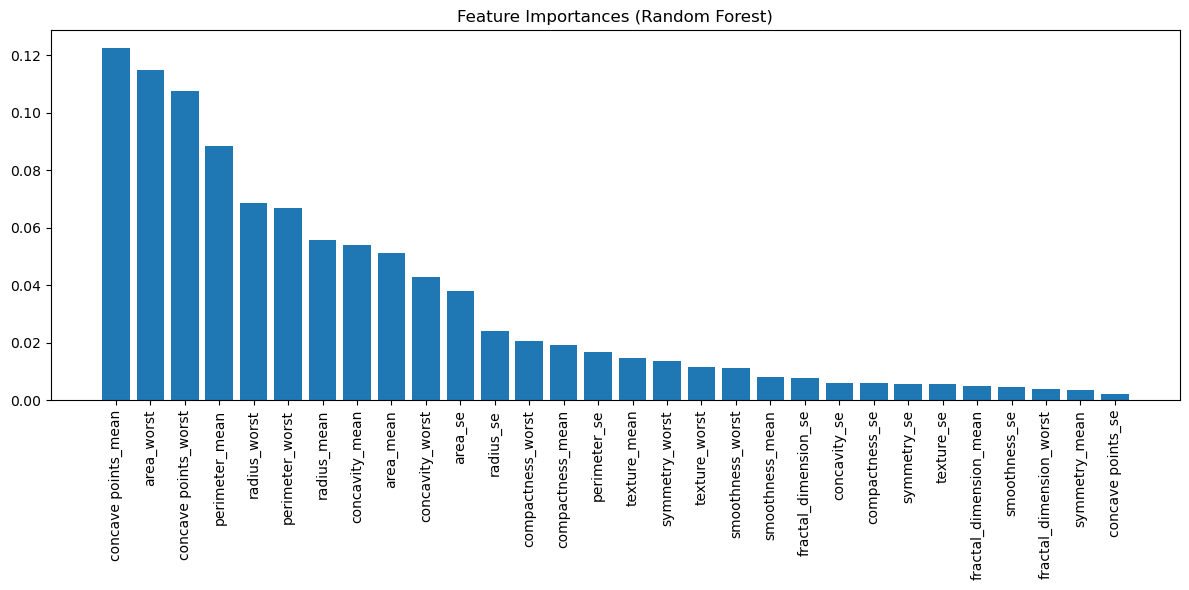

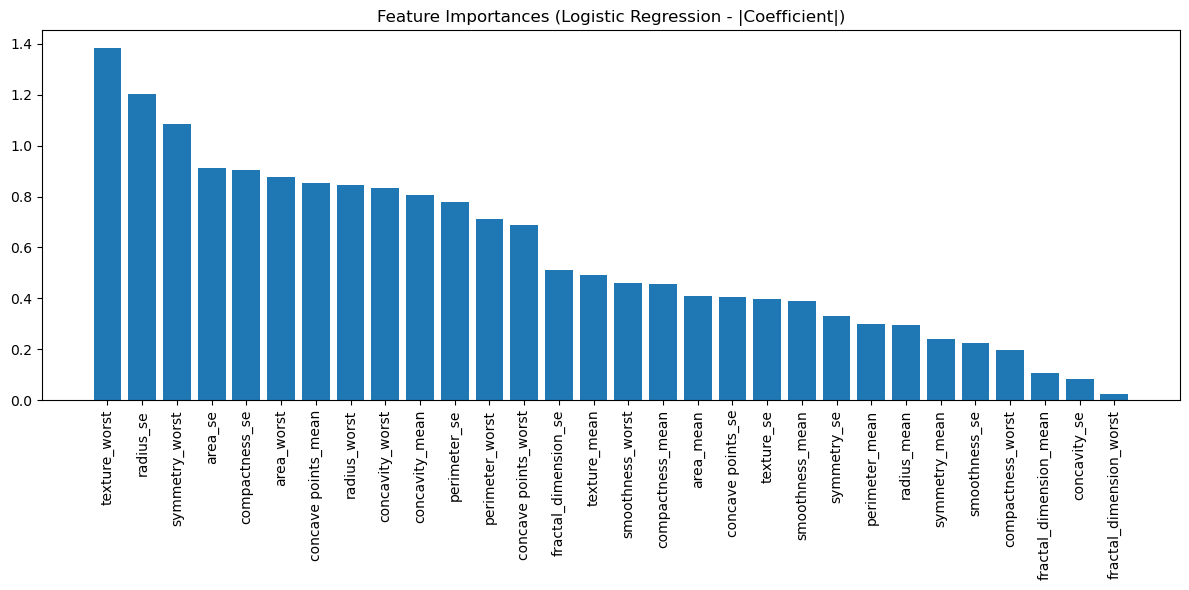

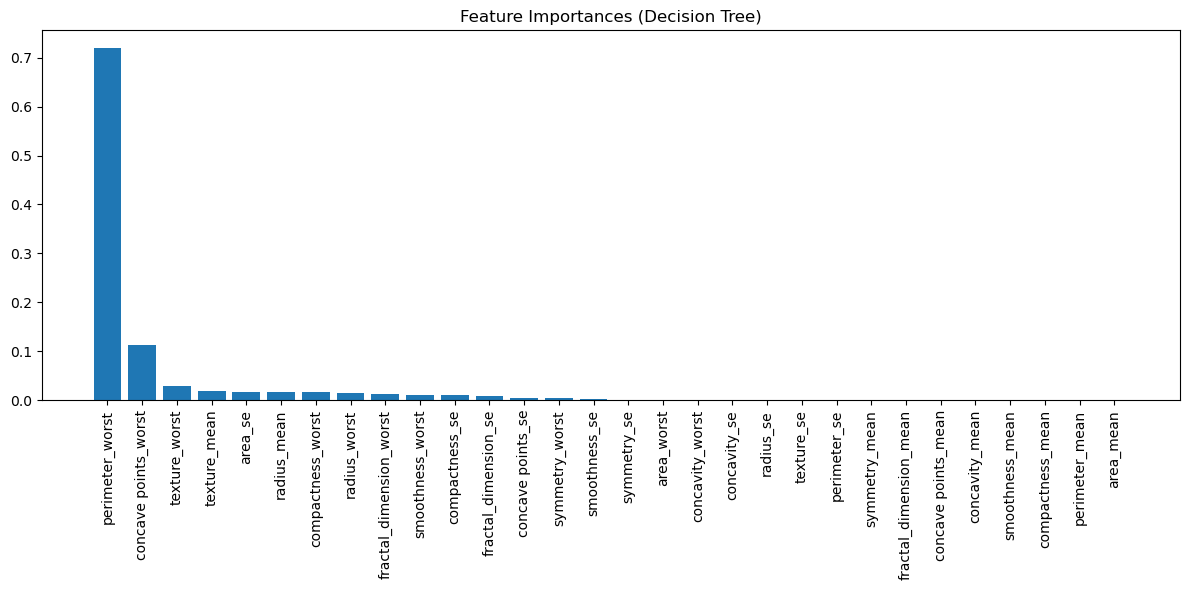

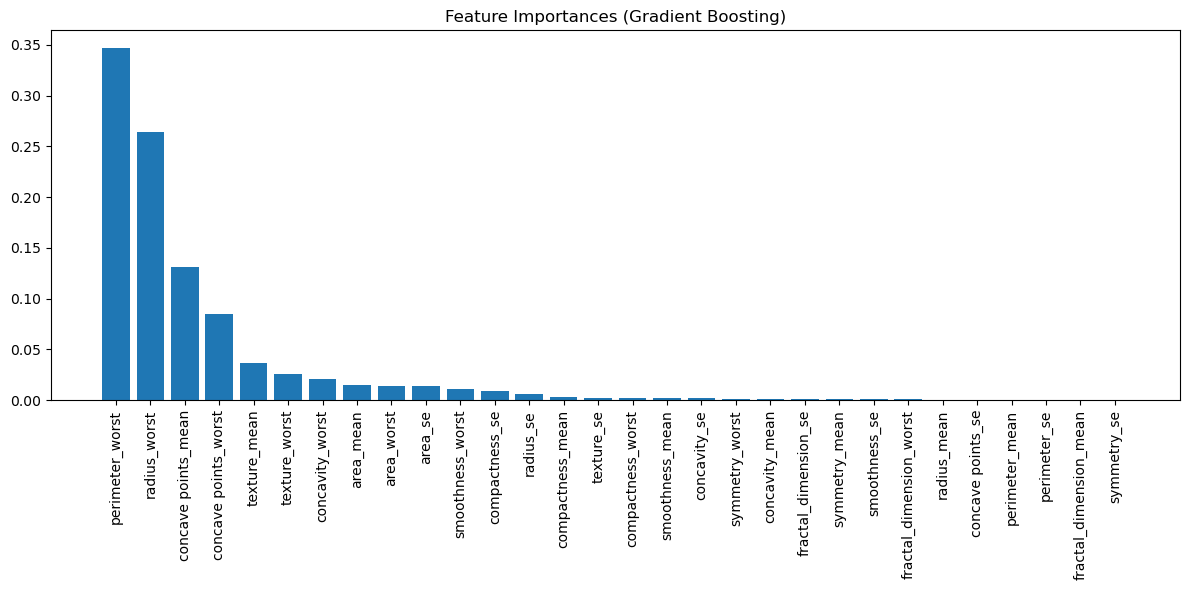

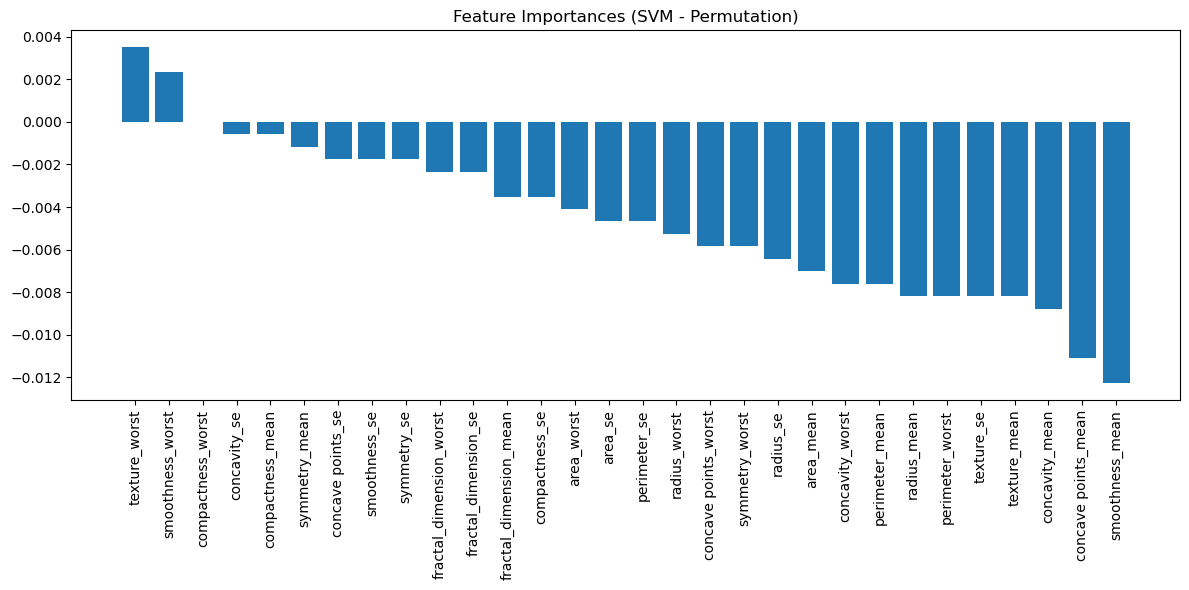

In [32]:
# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
# Data Cleaning
# Drop the 'id' column (not useful for prediction)
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

# Drop any column that is completely empty (e.g., the trailing unnamed column)
# This also removes columns that are all NaN.
df.dropna(axis=1, how='all', inplace=True)
# Verify that all features are numeric (they should be, but just in case)
for col in df.columns:
    if col != 'diagnosis':
        df[col] = pd.to_numeric(df[col], errors='coerce')
# After conversion, check again for NaNs (if coercion created any)
if df.isnull().sum().any():
    df.dropna(inplace=True)
    print("Dropped rows after numeric coercion.")

print("\nFinal dataset shape:", df.shape)
# Exploratory Data Analysis (EDA)
# Check diagnosis distribution
print("\nDiagnosis distribution:")
print(df['diagnosis'].value_counts())
# Visualize diagnosis counts
sns.countplot(x='diagnosis', data=df)
plt.title('Diagnosis Count (M=Malignant, B=Benign)')
plt.show()
# Summary statistics for features
print("\nFeature statistics:")
print(df.describe())
# Data Preprocessing
# Encode target: M -> 1, B -> 0
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  # M=1, B=0
# Separate features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
# Check class balance after encoding
print("\nEncoded target distribution:\n", y.value_counts())
# Train-test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
# Feature scaling (important for distance-based models like SVM, KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Model Building and Evaluation
# Define models to compare
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Naive Bayes': GaussianNB()
}
# Store results
results = {}
roc_curves = {}
# Train and evaluate each model
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    
    # For tree-based models, use unscaled data; for others use scaled data
    if name in ['Decision Tree', 'Random Forest', 'Gradient Boosting']:
        X_train_use = X_train
        X_test_use = X_test
    else:
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled
    
    # Train the model
    model.fit(X_train_use, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test_use)
    y_prob = model.predict_proba(X_test_use)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    # Confusion matrix and classification report
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred, target_names=['Benign', 'Malignant'])
    
    print(f"Accuracy: {acc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(cr)
    
    # ROC-AUC if probabilities available
    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)
        print(f"ROC-AUC: {roc_auc:.4f}")
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_curves[name] = (fpr, tpr, roc_auc)
    
    # Cross-validation (5-fold) on training set
    cv_scores = cross_val_score(model, X_train_use, y_train, cv=5, scoring='accuracy')
    print(f"Cross-validation accuracy (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Compare Model Performance
# ----------------------------
print("\n\n" + "="*50)
print("Model Comparison (Test Accuracy)")
print("="*50)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:20}: {acc:.4f}")
# Hyperparameter Tuning for Best Model
# Let's tune Random Forest (often performs well) using GridSearchCV
print("\n\n" + "="*50)
print("Hyperparameter Tuning for Random Forest")
print("="*50)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)  # Note: Random Forest does not need scaling

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print(f"Test accuracy with tuned model: {accuracy_score(y_test, y_pred_best):.4f}")


# Feature Importance (from Random Forest)
# ----------------------------
if hasattr(best_rf, 'feature_importances_'):
    importances = best_rf.feature_importances_
    indices = np.argsort(importances)[::-1]
    feature_names = X.columns
    
    plt.figure(figsize=(12, 6))
    plt.title("Feature Importances (Random Forest)")
    plt.bar(range(len(importances)), importances[indices], align="center")
    plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
    plt.tight_layout()
    plt.show()

# After training Logistic Regression model
log_model = models['Logistic Regression']
importances = np.abs(log_model.coef_[0])  # absolute values for importance
feature_names = X.columns

# Sort and plot
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12,6))
plt.title("Feature Importances (Logistic Regression - |Coefficient|)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

# After training Decision Tree
dt_model = models['Decision Tree']
importances = dt_model.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12,6))
plt.title("Feature Importances (Decision Tree)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

# After training Gradient Boosting
gb_model = models['Gradient Boosting']
importances = gb_model.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12,6))
plt.title("Feature Importances (Gradient Boosting)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

from sklearn.inspection import permutation_importance

# Choose a model, e.g., SVM
svm_model = models['SVM']

# Compute permutation importance on test set
perm_importance = permutation_importance(svm_model, X_test_scaled, y_test, 
                                         n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
feature_names = X.columns

indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12,6))
plt.title("Feature Importances (SVM - Permutation)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

knn_model = models['KNN']
perm_importance = permutation_importance(knn_model, X_test_scaled, y_test, 
                                         n_repeats=10, random_state=42)
# ... then plot as above


# **Decoding Malignancy: A Comparative Analysis of Machine Learning Classifiers for Breast Cancer Diagnosis**:

>**The ensemble models, particularly Random Forest and Gradient Boosting, delivered exceptional performance with over 97% accuracy, demonstrating that quantitative cellular features can reliably differentiate malignant from benign tumors—paving the way for AI-assisted diagnostic support.**

----------